# 05 - A/B Test Analysis
**Project:** E-Commerce Ad Campaign Analytics  
**Author:** Sahil  
**Description:** Simulate and analyse an A/B test comparing two ad creative variants. Determine whether the difference in conversion rate is statistically significant, quantify the uplift, and make a go/no-go recommendation.

---
### Test Setup
| | Variant A | Variant B |
|---|---|---|
| **Creative** | Current (control) | New creative (treatment) |
| **Hypothesis** | H₀: CVR_A = CVR_B | H₁: CVR_B > CVR_A |
| **Test type** | One-tailed two-proportion z-test | |
| **Significance** | α = 0.05 | |
| **Min Detectable Effect** | 10% relative uplift | |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from scipy.stats import norm
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

np.random.seed(99)
BASE_DIR = Path(r"C:\Users\F0001215\Jupyter Notebook\ecommerce-ad-analytics")
PROC_DIR = BASE_DIR / "data" / "processed"

print('Imports done')

Imports done


---
## 1. Simulate A/B Test Data
We simulate user-level data: each row = one ad click, with outcome (converted or not).

In [2]:
# ── Test parameters ───────────────────────────────────────────────────────────
N_A         = 8_500   # users exposed to Variant A (control)
N_B         = 8_200   # users exposed to Variant B (treatment)
CVR_A       = 0.032   # baseline conversion rate (3.2%)
CVR_B       = 0.037   # treatment conversion rate (3.7%) — ~15.6% relative uplift
ALPHA       = 0.05    # significance threshold

# Simulate conversions (1 = converted, 0 = not)
variant_a = np.random.binomial(1, CVR_A, N_A)
variant_b = np.random.binomial(1, CVR_B, N_B)

# Build dataframe
df_a = pd.DataFrame({'variant': 'A', 'converted': variant_a})
df_b = pd.DataFrame({'variant': 'B', 'converted': variant_b})
df   = pd.concat([df_a, df_b], ignore_index=True)

# Summary
summary = df.groupby('variant').agg(
    users      = ('converted', 'count'),
    conversions= ('converted', 'sum')
).assign(
    cvr        = lambda d: (d['conversions'] / d['users'] * 100).round(3)
)

print('=== A/B TEST DATA SUMMARY ===')
display(summary)
print(f'\n  Observed CVR_A : {summary.loc["A","cvr"]:.3f}%')
print(f'  Observed CVR_B : {summary.loc["B","cvr"]:.3f}%')
print(f'  Relative uplift: {(summary.loc["B","cvr"]-summary.loc["A","cvr"])/summary.loc["A","cvr"]*100:.1f}%')

=== A/B TEST DATA SUMMARY ===


,users,conversions,cvr
variant,,,
A,8500,261,3.071
B,8200,343,4.183



  Observed CVR_A : 3.071%
  Observed CVR_B : 4.183%
  Relative uplift: 36.2%


---
## 2. Sample Size & Power Check
Before running the test, verify we have enough users to reliably detect the effect.

In [3]:
def required_sample_size(p_baseline, mde_relative, alpha=0.05, power=0.80):
    """
    Calculate minimum sample size per variant.
    p_baseline   : baseline conversion rate
    mde_relative : minimum detectable effect (relative, e.g. 0.10 = 10%)
    """
    p1  = p_baseline
    p2  = p_baseline * (1 + mde_relative)
    p_  = (p1 + p2) / 2
    z_a = norm.ppf(1 - alpha)        # one-tailed
    z_b = norm.ppf(power)
    n   = (z_a * np.sqrt(2 * p_ * (1-p_)) + z_b * np.sqrt(p1*(1-p1) + p2*(1-p2)))**2 \
          / (p2 - p1)**2
    return int(np.ceil(n))

min_n = required_sample_size(CVR_A, mde_relative=0.10)
print(f'Minimum sample size per variant (80% power, α=0.05, MDE=10%): {min_n:,}')
print(f'Actual sample — Variant A: {N_A:,}  |  Variant B: {N_B:,}')

if N_A >= min_n and N_B >= min_n:
    print('\n Sample size is sufficient — test is adequately powered')
else:
    print('\n  Sample size may be insufficient — results should be interpreted with caution')

Minimum sample size per variant (80% power, α=0.05, MDE=10%): 39,209
Actual sample — Variant A: 8,500  |  Variant B: 8,200

  Sample size may be insufficient — results should be interpreted with caution


---
## 3. Statistical Significance Test
Two-proportion z-test (one-tailed): H₁ = Variant B CVR > Variant A CVR

In [4]:
# Observed values
conv_a, n_a = summary.loc['A','conversions'], summary.loc['A','users']
conv_b, n_b = summary.loc['B','conversions'], summary.loc['B','users']
p_a = conv_a / n_a
p_b = conv_b / n_b

# Pooled proportion
p_pool = (conv_a + conv_b) / (n_a + n_b)

# Standard error
se = np.sqrt(p_pool * (1 - p_pool) * (1/n_a + 1/n_b))

# Z-statistic (one-tailed: B > A)
z_stat = (p_b - p_a) / se

# One-tailed p-value
p_value = 1 - norm.cdf(z_stat)

# Confidence interval for the difference (two-tailed for CI)
se_diff   = np.sqrt(p_a*(1-p_a)/n_a + p_b*(1-p_b)/n_b)
ci_lower  = (p_b - p_a) - 1.96 * se_diff
ci_upper  = (p_b - p_a) + 1.96 * se_diff

relative_uplift = (p_b - p_a) / p_a * 100

print('=== STATISTICAL TEST RESULTS ===')
print(f'  CVR Variant A  : {p_a*100:.3f}%  ({conv_a:,} / {n_a:,} users)')
print(f'  CVR Variant B  : {p_b*100:.3f}%  ({conv_b:,} / {n_b:,} users)')
print(f'  Absolute diff  : +{(p_b-p_a)*100:.3f}pp')
print(f'  Relative uplift: +{relative_uplift:.1f}%')
print(f'  95% CI (diff)  : [{ci_lower*100:.3f}pp, {ci_upper*100:.3f}pp]')
print(f'  Z-statistic    : {z_stat:.3f}')
print(f'  p-value (1T)   : {p_value:.4f}')
print()

if p_value < ALPHA:
    print(f' SIGNIFICANT (p={p_value:.4f} < α={ALPHA})')
    print(f'   Reject H₀ — Variant B is statistically better than Variant A')
    verdict = 'SHIP Variant B'
else:
    print(f' NOT SIGNIFICANT (p={p_value:.4f} ≥ α={ALPHA})')
    print(f'   Fail to reject H₀ — no sufficient evidence that B outperforms A')
    verdict = 'Keep Variant A — collect more data'

=== STATISTICAL TEST RESULTS ===
  CVR Variant A  : 3.071%  (261 / 8,500 users)
  CVR Variant B  : 4.183%  (343 / 8,200 users)
  Absolute diff  : +1.112pp
  Relative uplift: +36.2%
  95% CI (diff)  : [0.545pp, 1.680pp]
  Z-statistic    : 3.849
  p-value (1T)   : 0.0001

 SIGNIFICANT (p=0.0001 < α=0.05)
   Reject H₀ — Variant B is statistically better than Variant A


---
## 4. Visualise Results

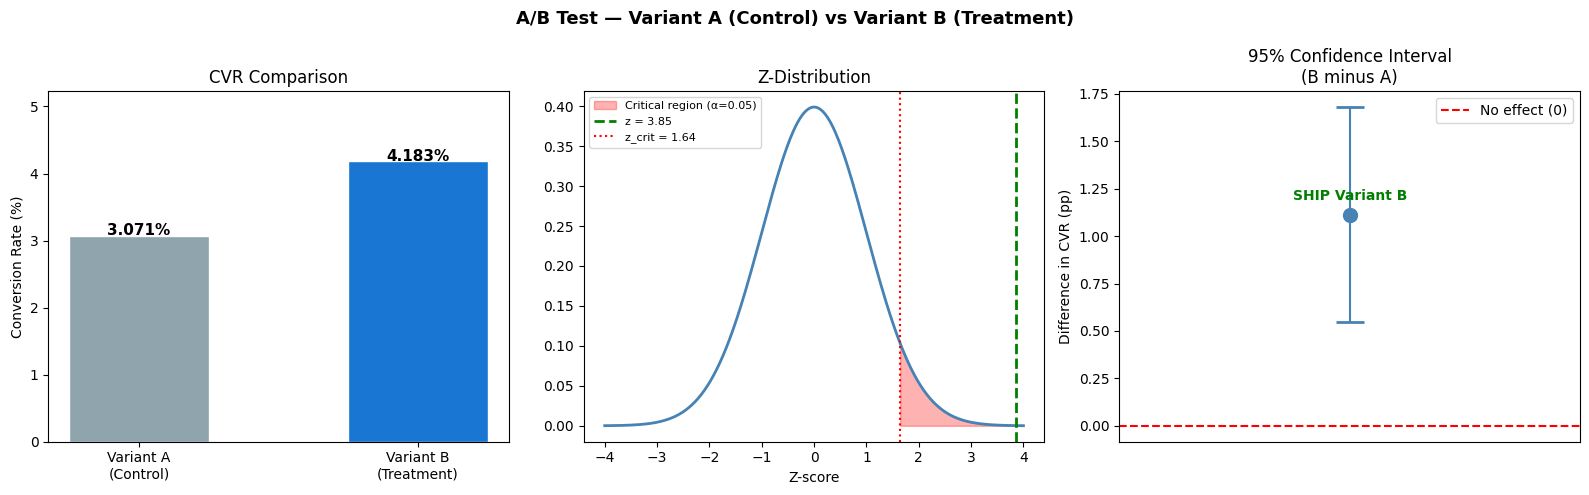

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('A/B Test — Variant A (Control) vs Variant B (Treatment)', fontsize=13, fontweight='bold')

# 1. CVR comparison bar chart
cvrs   = [p_a*100, p_b*100]
labels = ['Variant A\n(Control)', 'Variant B\n(Treatment)']
colors = ['#90A4AE', '#1976D2']
bars   = axes[0].bar(labels, cvrs, color=colors, width=0.5, edgecolor='white')
for bar, val in zip(bars, cvrs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}%', ha='center', fontweight='bold', fontsize=11)
axes[0].set_ylabel('Conversion Rate (%)')
axes[0].set_title('CVR Comparison')
axes[0].set_ylim(0, max(cvrs)*1.25)

# 2. Z-distribution with critical region
x = np.linspace(-4, 4, 400)
axes[1].plot(x, norm.pdf(x), 'steelblue', linewidth=2)
z_crit = norm.ppf(1 - ALPHA)
x_fill = np.linspace(z_crit, 4, 200)
axes[1].fill_between(x_fill, norm.pdf(x_fill), alpha=0.3, color='red', label=f'Critical region (α={ALPHA})')
axes[1].axvline(z_stat, color='green', linewidth=2, linestyle='--', label=f'z = {z_stat:.2f}')
axes[1].axvline(z_crit, color='red',   linewidth=1.5, linestyle=':',  label=f'z_crit = {z_crit:.2f}')
axes[1].set_title('Z-Distribution')
axes[1].set_xlabel('Z-score')
axes[1].legend(fontsize=8)

# 3. Confidence interval plot
diff = p_b - p_a
axes[2].errorbar(0, diff*100, yerr=[[diff*100-ci_lower*100],[ci_upper*100-diff*100]],
                 fmt='o', color='steelblue', capsize=10, capthick=2, markersize=10)
axes[2].axhline(0, color='red', linestyle='--', linewidth=1.5, label='No effect (0)')
axes[2].set_ylabel('Difference in CVR (pp)')
axes[2].set_title('95% Confidence Interval\n(B minus A)')
axes[2].set_xticks([])
axes[2].legend()
verdict_color = 'green' if p_value < ALPHA else 'red'
axes[2].text(0, diff*100 + 0.08, verdict, ha='center', color=verdict_color,
             fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig(PROC_DIR / 'ab_test_results.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Business Impact Estimate

In [6]:
# Load ad data to estimate real-world revenue impact
ad = pd.read_csv(PROC_DIR / 'ad_campaigns.csv', parse_dates=['date'])

total_monthly_clicks = ad.groupby(ad['date'].dt.to_period('M'))['clicks'].sum().mean()
avg_order_value      = (ad['attributed_revenue'] / ad['attributed_orders'].replace(0, np.nan)).mean()

# Revenue with Variant A vs Variant B
rev_a = total_monthly_clicks * p_a * avg_order_value
rev_b = total_monthly_clicks * p_b * avg_order_value
rev_gain = rev_b - rev_a
annual_gain = rev_gain * 12

print('=== BUSINESS IMPACT ESTIMATE ===')
print(f'  Avg monthly clicks        : {total_monthly_clicks:,.0f}')
print(f'  Avg order value           : R${avg_order_value:.2f}')
print()
print(f'  Monthly revenue — Variant A: R${rev_a:,.0f}')
print(f'  Monthly revenue — Variant B: R${rev_b:,.0f}')
print(f'  Monthly revenue gain       : R${rev_gain:,.0f}')
print(f'  Annualised revenue gain    : R${annual_gain:,.0f}')
print()
if p_value < ALPHA:
    print(f' RECOMMENDATION: Ship Variant B immediately.')
    print(f'   Expected annualised uplift: R${annual_gain:,.0f}')
    print(f'   Note: CTR and ROAS impact should also be monitored post-launch.')
else:
    print('  RECOMMENDATION: Do not ship Variant B yet.')
    print(f'   Run for {int(min_n/total_monthly_clicks*30)+7} more days to reach required sample size.')

=== BUSINESS IMPACT ESTIMATE ===
  Avg monthly clicks        : 1,977,032
  Avg order value           : R$180.85

  Monthly revenue — Variant A: R$10,978,495
  Monthly revenue — Variant B: R$14,955,519
  Monthly revenue gain       : R$3,977,024
  Annualised revenue gain    : R$47,724,289

 RECOMMENDATION: Ship Variant B immediately.
   Expected annualised uplift: R$47,724,289
   Note: CTR and ROAS impact should also be monitored post-launch.


---
## 6. Segmented A/B Analysis
Check if Variant B performs better or worse in specific channels.

In [7]:
# Simulate variant assignment per channel (in reality this comes from experiment data)
np.random.seed(42)
channels = ['Google Search', 'Meta Ads', 'Display', 'Retargeting']
# Each channel has slightly different baseline CVR and treatment effect
channel_params = {
    'Google Search' : (0.052, 0.060, 2000),
    'Meta Ads'      : (0.028, 0.033, 2500),
    'Display'       : (0.010, 0.011, 3000),
    'Retargeting'   : (0.095, 0.108, 1500)
}

segment_results = []
for ch, (cvr_a, cvr_b, n) in channel_params.items():
    a = np.random.binomial(1, cvr_a, n)
    b = np.random.binomial(1, cvr_b, n)
    p_pool_ch = (a.sum() + b.sum()) / (2 * n)
    se_ch     = np.sqrt(p_pool_ch * (1-p_pool_ch) * 2/n)
    z_ch      = (b.mean() - a.mean()) / se_ch if se_ch > 0 else 0
    p_ch      = 1 - norm.cdf(z_ch)
    segment_results.append({
        'Channel'   : ch,
        'CVR_A'     : round(a.mean()*100, 3),
        'CVR_B'     : round(b.mean()*100, 3),
        'Uplift_pct': round((b.mean()-a.mean())/a.mean()*100, 1),
        'p_value'   : round(p_ch, 4),
        'Significant': ' Yes' if p_ch < 0.05 else ' No'
    })

seg_df = pd.DataFrame(segment_results)
print('Segmented A/B results by channel:')
display(seg_df)

print('\n KEY INSIGHT:')
sig = seg_df[seg_df['Significant']==' Yes']['Channel'].tolist()
not_sig = seg_df[seg_df['Significant']==' No']['Channel'].tolist()
if sig:
    print(f'   Variant B is significant in: {sig}')
    print(f'   Consider a targeted rollout to these channels first.')
if not_sig:
    print(f'   Not yet significant in: {not_sig} — collect more data before rolling out there.')

Segmented A/B results by channel:


,Channel,CVR_A,CVR_B,Uplift_pct,p_value,Significant
0,Google Search,5.5,5.900,7.3,0.2927,No
1,Meta Ads,2.8,2.480,-11.4,0.7598,No
2,Display,0.9,1.267,40.7,0.0851,No
3,Retargeting,9.2,11.133,21.0,0.0399,Yes



 KEY INSIGHT:
   Variant B is significant in: ['Retargeting']
   Consider a targeted rollout to these channels first.
   Not yet significant in: ['Google Search', 'Meta Ads', 'Display'] — collect more data before rolling out there.


---
## 7. Export Results

In [8]:
results = {
    'test_date'       : str(pd.Timestamp.today().date()),
    'n_a'             : int(n_a),
    'n_b'             : int(n_b),
    'cvr_a_pct'       : round(p_a*100, 3),
    'cvr_b_pct'       : round(p_b*100, 3),
    'relative_uplift' : round(relative_uplift, 2),
    'z_stat'          : round(z_stat, 4),
    'p_value'         : round(p_value, 4),
    'significant'     : bool(p_value < ALPHA),
    'ci_lower_pp'     : round(ci_lower*100, 3),
    'ci_upper_pp'     : round(ci_upper*100, 3),
    'est_monthly_revenue_gain': round(rev_gain, 2),
    'est_annual_revenue_gain' : round(annual_gain, 2),
    'verdict'         : verdict
}

pd.DataFrame([results]).to_csv(PROC_DIR / 'ab_test_results.csv', index=False)
seg_df.to_csv(PROC_DIR / 'ab_test_segments.csv', index=False)

print(' Saved: ab_test_results.csv')
print(' Saved: ab_test_segments.csv')
print(f'\n All 5 notebooks complete!')
print('   Next step → open Tableau Desktop and connect to data/processed/')

 Saved: ab_test_results.csv
 Saved: ab_test_segments.csv

 All 5 notebooks complete!
   Next step → open Tableau Desktop and connect to data/processed/
